# LHEH5/HDF5 example

In [12]:
import shutil
from tempfile import NamedTemporaryFile
from urllib.request import urlopen

import hist

import pylhe

In [29]:
url = "https://zenodo.org/records/7751000/files/l2_1.hdf5?download=1"
with urlopen(url) as response, NamedTemporaryFile(suffix=".hdf5") as tmp:
    shutil.copyfileobj(response, tmp)
    tmp.flush()

    lhe = pylhe.LHEFile.fromfile(tmp.name)

In [30]:
arr = pylhe.to_awkward(lhe)

In [31]:
higgs = arr.particles[(abs(arr.particles.id) == 25) & (arr.particles.status == 1)]

In [32]:
mass_hist = hist.Hist.new.Reg(30, 0, 50).Int64()

In [33]:
# only take first higgs per event
mass_hist.fill(
    higgs.vector[:, 0].pt,
    weight=arr.eventinfo.weight,
)

Hist(Regular(30, 0, 50, label='Axis 0'), storage=Int64()) # Sum: 7047002756.0 (22394099927.0 with flow)

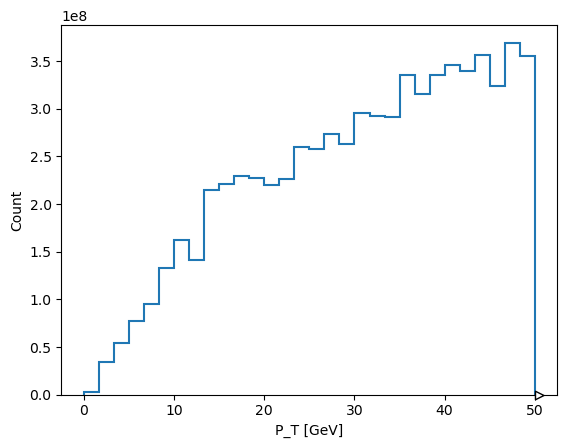

In [34]:
artists = mass_hist.plot1d()
ax = artists[0].stairs.axes
# ax.set_yscale("log")
ax.set_xlabel("P_T [GeV]")
ax.set_ylabel("Count");